In [1]:

import opendatasets as od
od.download("https://www.kaggle.com/datasets/umairshahpirzada/birds-20-species-image-classification?select=images+to+predict")opendatasets

SyntaxError: invalid syntax (1880816961.py, line 2)

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
test=keras.utils.image_dataset_from_directory(
    directory='/content/birds-20-species-image-classification/test',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256)
)

train=keras.utils.image_dataset_from_directory(
    directory='/content/birds-20-species-image-classification/train',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256)
)

Found 100 files belonging to 20 classes.
Found 3208 files belonging to 20 classes.


In [4]:
# Normalize
def process(image,label):
    image=tf.cast(image/255. ,tf.float32)
    return image,label

train=train.map(process)
test=test.map(process)

In [5]:
model = Sequential()

model.add(Conv2D(16,(3,3),activation='relu',
                 padding='same',
                 input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(16,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())



model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())


model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(512,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dense(20,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,104,772 (8.03 MB)

 Trainable params: 2,104,772 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(train,epochs=20,validation_data=test)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.0689 - loss: 2.9208 - val_accuracy: 0.1000 - val_loss: 2.6902
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.1527 - loss: 2.5811 - val_accuracy: 0.2300 - val_loss: 2.4081
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2406 - loss: 2.3496 - val_accuracy: 0.3300 - val_loss: 2.1918
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3563 - loss: 2.0027 - val_accuracy: 0.4000 - val_loss: 1.8408
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4791 - loss: 1.6445 - val_accuracy: 0.5300 - val_loss: 1.5734
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5770 - loss: 1.3113 - val_accuracy: 0.6400 - val_loss: 1.3501
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6633 - loss: 1.0295 - val_accuracy: 0.6100 - val_loss: 1.2697
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7531 - loss: 0.7674 - val_ac

In [14]:
from google import genai

client = genai.Client(api_key="AQ.Ab8RN6IgeaPECI6HE_MfuV-K5fFz2FEnUkybDXeZ__5Mt4m2RQ")

interaction = client.interactions.create(
    model="gemini-3.5-flash",
    input="Explain how AI works in a few words"
)
print(interaction.output_text)

AI analyzes data, finds patterns, and makes predictions.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


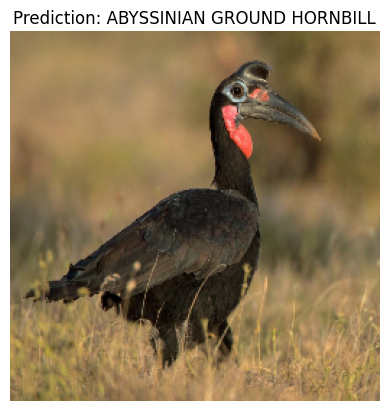

Bird: ABYSSINIAN GROUND HORNBILL
Confidence: 98.94%

Bird Information:

The **Abyssinian Ground Hornbill** (*Bucorvus abyssinicus*) is a truly magnificent and iconic bird of the African savannas. Known for its striking appearance and formidable presence, it's one of the two species of ground hornbills (the other being the Southern Ground Hornbill).

Here's a detailed look at this fascinating bird:

---

### **Abyssinian Ground Hornbill**

**Scientific Name:** *Bucorvus abyssinicus*

---

**Habitat:**
Abyssinian Ground Hornbills are found in the semi-arid to sub-humid savannas, grasslands, and open woodlands of **sub-Saharan Africa**, stretching across a broad belt from Senegal and Gambia in the west, through Nigeria, Cameroon, Chad, Sudan, Ethiopia, Eritrea, Uganda, and Kenya. They prefer open areas with scattered trees, avoiding dense forests. As their name suggests, they are predominantly terrestrial, spending most of their time walking and foraging on the ground.

---

**Diet:**
The

In [22]:
# Load image
img = cv2.imread('/content/Abyssinian Ground Hornbill.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))

# Normalize
img = img.astype('float32') / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img)

predicted_index = np.argmax(pred)

predicted_class = class_names[predicted_index]

confidence = np.max(pred) * 100


plt.imshow(np.squeeze(img)) # Remove the batch dimension for plotting
plt.title(f"Prediction: {class_names[predicted_index]}")
plt.axis('off')
plt.show()

print(f"Bird: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

# Ask Gemini
prompt = f"""
Tell me everything about the bird '{predicted_class}'.

Include:
- Scientific Name
- Habitat
- Diet
- Lifespan
- Wingspan
- Weight
- Conservation Status
- Interesting Facts
"""

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print("\nBird Information:\n")
print(response.text)